# 6.1b - Residual Similarity and Shock Disagreement

This notebook quantifies how similar the orthogonalized communication shocks are across the six LLMs, then identifies the specific meetings and time periods where that similarity breaks down. It is designed to support the paper subsection on how LLM disagreement affects downstream shock estimates.

Headline evidence:
- pairwise **Pearson correlation** of shock series within each bank
- pairwise **same-sign rate** using a small zero band around zero

Complementary divergence evidence:
- cross-LLM shock range by meeting
- cross-LLM shock standard deviation by meeting
- number of pairwise sign flips out of 15 model pairs


In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path

import matplotlib
from IPython import get_ipython

ip = get_ipython()
if ip is None:
    matplotlib.use("Agg")
elif "IPKernelApp" in getattr(ip, "config", {}):
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import seaborn as sns
    HAVE_SEABORN = True
except Exception:
    sns = None
    HAVE_SEABORN = False

if HAVE_SEABORN:
    sns.set_theme(style="whitegrid", font_scale=0.95)
else:
    plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

ROOT = Path.cwd().resolve()
if not (ROOT / "output").exists() and (ROOT.parent / "output").exists():
    ROOT = ROOT.parent
elif not (ROOT / "output").exists() and (Path("..").resolve() / "output").exists():
    ROOT = Path("..").resolve()
OUTPUT_DIR = ROOT / "output"
RESIDUALS_DIR = OUTPUT_DIR / "causal-machinery" / "residuals"
ROBUSTNESS_DIR = OUTPUT_DIR / "causal-machinery" / "robustness"
FIGURE_DIR = OUTPUT_DIR / "figures"
ROBUSTNESS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

LLMS = ["deepseekv3", "gemini25flash", "gpt-4o", "llama33", "mistrallarge_or", "qwen25_72b"]
BANKS = ["fed", "ecb", "boe"]
ZERO_BAND = 0.02
PAIR_COUNT = len(list(combinations(LLMS, 2)))

LLM_SHORT = {
    "deepseekv3": "DeepSeek",
    "gemini25flash": "Gemini",
    "gpt-4o": "GPT-4o",
    "llama33": "Llama",
    "mistrallarge_or": "Mistral",
    "qwen25_72b": "Qwen",
}
LLM_COLOR = {
    "deepseekv3": "#1b9e77",
    "gemini25flash": "#d95f02",
    "gpt-4o": "#7570b3",
    "llama33": "#e7298a",
    "mistrallarge_or": "#66a61e",
    "qwen25_72b": "#e6ab02",
}
BANK_LABEL = {"fed": "Federal Reserve", "ecb": "ECB", "boe": "BoE"}

print(f"Residual directory: {RESIDUALS_DIR}")
print(f"Seaborn available: {HAVE_SEABORN}")
print(f"Expected pairwise comparisons per bank: {PAIR_COUNT}")
print(f"Zero band for sign agreement: +/-{ZERO_BAND:.2f}")


Residual directory: C:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\output\causal-machinery\residuals
Seaborn available: True
Expected pairwise comparisons per bank: 15
Zero band for sign agreement: +/-0.02


## 1. Load and Harmonize Residual Shocks

Read all 18 residual CSVs, check duplicates and alignment, then build one wide shock panel per bank.


In [2]:
shock_dfs: dict[str, pd.DataFrame] = {}
duplicate_rows = []

for bank in BANKS:
    series = {}
    meeting_counts = []
    print(f"\n=== {BANK_LABEL[bank]} ({bank.upper()}) ===")
    for llm in LLMS:
        path = RESIDUALS_DIR / f"{bank}_{llm}_residuals.csv"
        if not path.exists():
            raise FileNotFoundError(f"Missing residual file: {path}")
        df = pd.read_csv(path)
        if list(df.columns) != ["date", "shock"]:
            raise ValueError(f"Unexpected schema in {path.name}: {list(df.columns)}")
        df["date"] = pd.to_datetime(df["date"])
        dup_count = int(df["date"].duplicated().sum())
        duplicate_rows.append({"bank": bank, "llm": llm, "n_duplicate_dates": dup_count})
        meeting_counts.append({"llm": llm, "n_meetings": len(df)})
        series[llm] = df.set_index("date")["shock"].rename(llm)
        print(f"  {LLM_SHORT[llm]:<8} meetings={len(df):>3}  duplicate_dates={dup_count}")
    wide = pd.concat(series.values(), axis=1).sort_index()
    wide = wide[LLMS]
    if wide.columns.tolist() != LLMS:
        raise AssertionError(f"Column order mismatch for {bank}")
    if wide.isna().any().any():
        na_counts = wide.isna().sum()
        raise AssertionError(f"Missing aligned dates for {bank}:\n{na_counts}")
    counts_set = {row['n_meetings'] for row in meeting_counts}
    assert len(counts_set) == 1, f"Meeting counts differ across LLMs for {bank}: {meeting_counts}"
    shock_dfs[bank] = wide
    print(f"  -> aligned panel shape: {wide.shape}")

duplicate_check = pd.DataFrame(duplicate_rows)
print("\nDuplicate-date check (should all be zero):")
display(duplicate_check)

for bank, sdf in shock_dfs.items():
    print(f"{bank.upper()}: {len(sdf)} meetings, columns={sdf.columns.tolist()}")



=== Federal Reserve (FED) ===
  DeepSeek meetings= 73  duplicate_dates=0
  Gemini   meetings= 73  duplicate_dates=0
  GPT-4o   meetings= 73  duplicate_dates=0
  Llama    meetings= 73  duplicate_dates=0
  Mistral  meetings= 73  duplicate_dates=0
  Qwen     meetings= 73  duplicate_dates=0
  -> aligned panel shape: (73, 6)

=== ECB (ECB) ===
  DeepSeek meetings= 89  duplicate_dates=0
  Gemini   meetings= 89  duplicate_dates=0
  GPT-4o   meetings= 89  duplicate_dates=0
  Llama    meetings= 89  duplicate_dates=0
  Mistral  meetings= 89  duplicate_dates=0
  Qwen     meetings= 89  duplicate_dates=0
  -> aligned panel shape: (89, 6)

=== BoE (BOE) ===
  DeepSeek meetings= 44  duplicate_dates=0
  Gemini   meetings= 44  duplicate_dates=0
  GPT-4o   meetings= 44  duplicate_dates=0
  Llama    meetings= 44  duplicate_dates=0
  Mistral  meetings= 44  duplicate_dates=0
  Qwen     meetings= 44  duplicate_dates=0
  -> aligned panel shape: (44, 6)

Duplicate-date check (should all be zero):


,bank,llm,n_duplicate_dates
0,fed,deepseekv3,0
1,fed,gemini25flash,0
2,fed,gpt-4o,0
3,fed,llama33,0
4,fed,mistrallarge_or,0
5,fed,qwen25_72b,0
6,ecb,deepseekv3,0
7,ecb,gemini25flash,0
8,ecb,gpt-4o,0
9,ecb,llama33,0


FED: 73 meetings, columns=['deepseekv3', 'gemini25flash', 'gpt-4o', 'llama33', 'mistrallarge_or', 'qwen25_72b']
ECB: 89 meetings, columns=['deepseekv3', 'gemini25flash', 'gpt-4o', 'llama33', 'mistrallarge_or', 'qwen25_72b']
BOE: 44 meetings, columns=['deepseekv3', 'gemini25flash', 'gpt-4o', 'llama33', 'mistrallarge_or', 'qwen25_72b']


## 2. Quantify Cross-LLM Similarity

The headline measures are mean pairwise Pearson correlation and mean pairwise same-sign rate within each bank.


In [3]:
def sign_with_band(values: pd.Series | np.ndarray, zero_band: float = ZERO_BAND) -> pd.Series:
    s = pd.Series(values, copy=False)
    out = pd.Series(np.where(s > zero_band, 1, np.where(s < -zero_band, -1, 0)), index=s.index)
    return out.astype(int)


def build_pairwise_metrics(bank: str, sdf: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    pearson = sdf.corr(method="pearson")
    spearman = sdf.corr(method="spearman")
    same_sign = pd.DataFrame(np.eye(len(LLMS)), index=LLMS, columns=LLMS, dtype=float)
    sign_flip = pd.DataFrame(np.zeros((len(LLMS), len(LLMS))), index=LLMS, columns=LLMS, dtype=float)
    signed = sdf.apply(sign_with_band, zero_band=ZERO_BAND)
    rows = []

    for left, right in combinations(LLMS, 2):
        left_vals = sdf[left]
        right_vals = sdf[right]
        left_sign = signed[left]
        right_sign = signed[right]
        same_rate = float((left_sign == right_sign).mean())
        flip_rate = float((left_sign * right_sign == -1).mean())
        near_zero_mismatch = float(((left_sign == 0) ^ (right_sign == 0)).mean())
        rows.append({
            "bank": bank,
            "llm_a": left,
            "llm_b": right,
            "pearson": float(pearson.loc[left, right]),
            "spearman": float(spearman.loc[left, right]),
            "same_sign_rate": same_rate,
            "sign_flip_rate": flip_rate,
            "near_zero_mismatch_rate": near_zero_mismatch,
            "n_meetings": int(len(sdf)),
        })
        same_sign.loc[left, right] = same_rate
        same_sign.loc[right, left] = same_rate
        sign_flip.loc[left, right] = flip_rate
        sign_flip.loc[right, left] = flip_rate

    pairwise = pd.DataFrame(rows).sort_values(["bank", "pearson"], ascending=[True, False]).reset_index(drop=True)
    matrices = {"pearson": pearson, "spearman": spearman, "same_sign": same_sign, "sign_flip": sign_flip}
    return pairwise, matrices


pairwise_tables = []
similarity_mats: dict[str, dict[str, pd.DataFrame]] = {}
summary_rows = []

for bank, sdf in shock_dfs.items():
    pairwise, matrices = build_pairwise_metrics(bank, sdf)
    pairwise_tables.append(pairwise)
    similarity_mats[bank] = matrices
    summary_rows.append({
        "bank": bank,
        "bank_label": BANK_LABEL[bank],
        "n_meetings": len(sdf),
        "n_pairs": len(pairwise),
        "mean_pairwise_pearson": pairwise["pearson"].mean(),
        "min_pairwise_pearson": pairwise["pearson"].min(),
        "max_pairwise_pearson": pairwise["pearson"].max(),
        "mean_pairwise_spearman": pairwise["spearman"].mean(),
        "mean_same_sign_rate": pairwise["same_sign_rate"].mean(),
        "mean_sign_flip_rate": pairwise["sign_flip_rate"].mean(),
        "mean_near_zero_mismatch_rate": pairwise["near_zero_mismatch_rate"].mean(),
    })

pairwise_similarity = pd.concat(pairwise_tables, ignore_index=True)
bank_summary = pd.DataFrame(summary_rows).sort_values("bank").reset_index(drop=True)

print("Bank-level summary:")
display(
    bank_summary.style.format({
        "mean_pairwise_pearson": "{:.3f}",
        "min_pairwise_pearson": "{:.3f}",
        "max_pairwise_pearson": "{:.3f}",
        "mean_pairwise_spearman": "{:.3f}",
        "mean_same_sign_rate": "{:.1%}",
        "mean_sign_flip_rate": "{:.1%}",
        "mean_near_zero_mismatch_rate": "{:.1%}",
    })
)

print("\nAppendix-style pairwise table (top rows):")
display(
    pairwise_similarity.head(18).style.format({
        "pearson": "{:.3f}",
        "spearman": "{:.3f}",
        "same_sign_rate": "{:.1%}",
        "sign_flip_rate": "{:.1%}",
        "near_zero_mismatch_rate": "{:.1%}",
    })
)


Bank-level summary:


,bank,bank_label,n_meetings,n_pairs,mean_pairwise_pearson,min_pairwise_pearson,max_pairwise_pearson,mean_pairwise_spearman,mean_same_sign_rate,mean_sign_flip_rate,mean_near_zero_mismatch_rate
0,boe,BoE,44,15,0.894,0.826,0.931,0.830,70.6%,3.6%,25.8%
1,ecb,ECB,89,15,0.784,0.688,0.843,0.751,67.0%,9.0%,24.0%
2,fed,Federal Reserve,73,15,0.897,0.863,0.923,0.853,73.4%,4.9%,21.6%



Appendix-style pairwise table (top rows):


,bank,llm_a,llm_b,pearson,spearman,same_sign_rate,sign_flip_rate,near_zero_mismatch_rate,n_meetings
0,fed,gemini25flash,llama33,0.923,0.920,82.2%,1.4%,16.4%,73
1,fed,llama33,mistrallarge_or,0.917,0.897,72.6%,1.4%,26.0%,73
2,fed,deepseekv3,gpt-4o,0.913,0.850,74.0%,6.8%,19.2%,73
3,fed,gpt-4o,mistrallarge_or,0.912,0.870,72.6%,2.7%,24.7%,73
4,fed,gemini25flash,qwen25_72b,0.902,0.875,76.7%,1.4%,21.9%,73
5,fed,deepseekv3,gemini25flash,0.901,0.823,72.6%,9.6%,17.8%,73
6,fed,gpt-4o,qwen25_72b,0.899,0.842,72.6%,4.1%,23.3%,73
7,fed,gpt-4o,llama33,0.897,0.875,74.0%,5.5%,20.5%,73
8,fed,gemini25flash,mistrallarge_or,0.897,0.872,74.0%,5.5%,20.5%,73
9,fed,deepseekv3,mistrallarge_or,0.894,0.836,68.5%,4.1%,27.4%,73


In [4]:
def draw_matrix_heatmap(ax, data: pd.DataFrame, title: str, cmap: str, vmin: float, vmax: float, fmt: str = ".2f"):
    if HAVE_SEABORN:
        sns.heatmap(
            data,
            ax=ax,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            cbar=False,
            square=True,
            xticklabels=[LLM_SHORT[c] for c in data.columns],
            yticklabels=[LLM_SHORT[i] for i in data.index],
        )
    else:
        im = ax.imshow(data.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
        ax.set_xticks(np.arange(len(data.columns)))
        ax.set_yticks(np.arange(len(data.index)))
        ax.set_xticklabels([LLM_SHORT[c] for c in data.columns], rotation=45, ha="right")
        ax.set_yticklabels([LLM_SHORT[i] for i in data.index])
        for i in range(len(data.index)):
            for j in range(len(data.columns)):
                val = data.iloc[i, j]
                color = "white" if val > (vmin + vmax) / 2 else "black"
                ax.text(j, i, format(val, fmt), ha="center", va="center", color=color, fontsize=8)
        return im
    return None


## 3. Visualize Similarity

Three Pearson heatmaps and three same-sign heatmaps show the average similarity directly. A compact bank-level summary figure gives paper-friendly headline values. The color scales are tightened so cross-bank differences are easier to read in print.


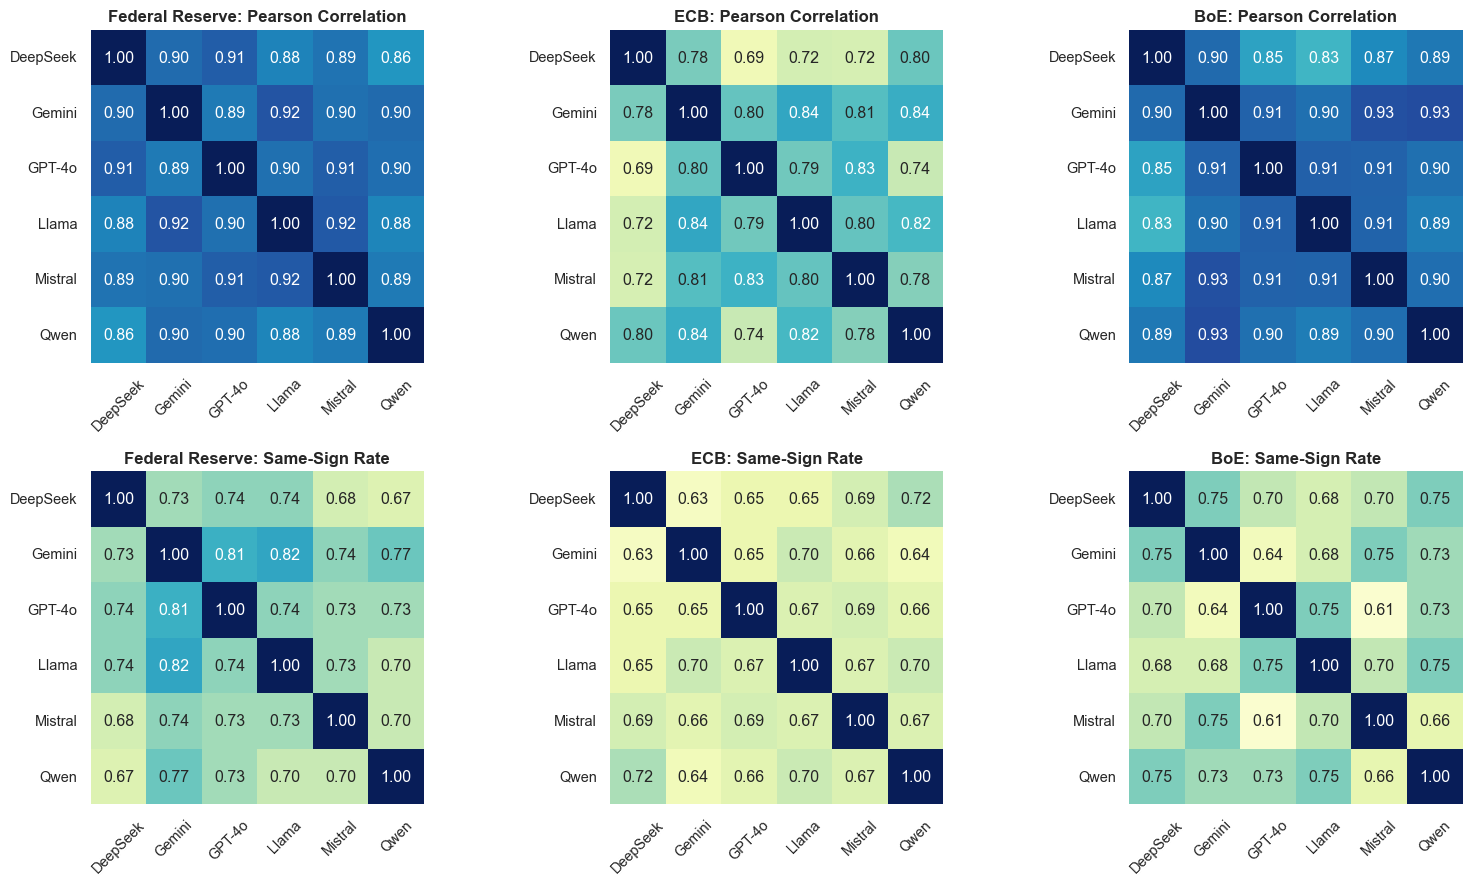

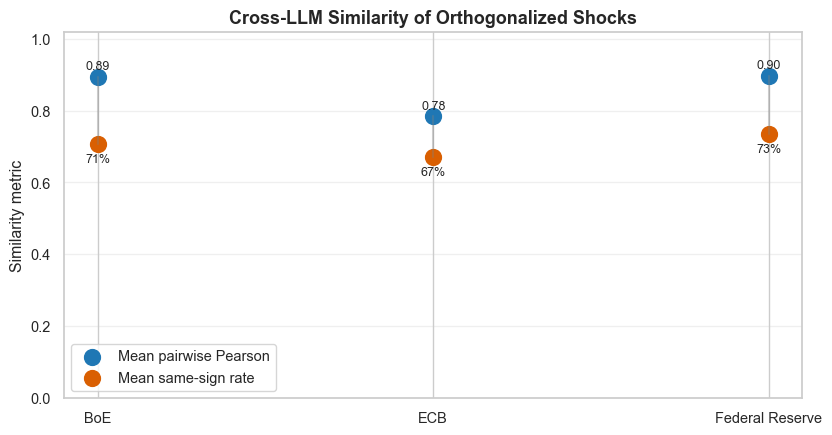

In [5]:
PEARSON_CMAP = "YlGnBu"
SIGN_CMAP = "YlGnBu"
PEARSON_VMIN, PEARSON_VMAX = 0.65, 1.00
SIGN_VMIN, SIGN_VMAX = 0.60, 1.00

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
order = LLMS
ims = []

for col, bank in enumerate(BANKS):
    pearson_mat = similarity_mats[bank]["pearson"].loc[order, order]
    same_mat = similarity_mats[bank]["same_sign"].loc[order, order]
    im = draw_matrix_heatmap(axes[0, col], pearson_mat, f"{BANK_LABEL[bank]}: Pearson Correlation", PEARSON_CMAP, PEARSON_VMIN, PEARSON_VMAX)
    if im is not None:
        ims.append((im, axes[0, col]))
    axes[0, col].set_title(f"{BANK_LABEL[bank]}: Pearson Correlation", fontsize=12, fontweight="bold")
    axes[0, col].tick_params(axis="x", rotation=45)
    axes[0, col].tick_params(axis="y", rotation=0)

    im = draw_matrix_heatmap(axes[1, col], same_mat, f"{BANK_LABEL[bank]}: Same-Sign Rate", SIGN_CMAP, SIGN_VMIN, SIGN_VMAX)
    if im is not None:
        ims.append((im, axes[1, col]))
    axes[1, col].set_title(f"{BANK_LABEL[bank]}: Same-Sign Rate", fontsize=12, fontweight="bold")
    axes[1, col].tick_params(axis="x", rotation=45)
    axes[1, col].tick_params(axis="y", rotation=0)

if not HAVE_SEABORN and ims:
    fig.colorbar(ims[0][0], ax=axes[0, :], shrink=0.8, label="Pearson correlation")
    fig.colorbar(ims[-1][0], ax=axes[1, :], shrink=0.8, label="Same-sign rate")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "residual_similarity_heatmaps.png", dpi=160, bbox_inches="tight")
plt.show()

summary_plot = bank_summary.copy()
summary_plot["mean_same_sign_pct"] = summary_plot["mean_same_sign_rate"] * 100

fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(summary_plot))
ax.scatter(x, summary_plot["mean_pairwise_pearson"], s=130, color="#1f77b4", label="Mean pairwise Pearson")
ax.scatter(x, summary_plot["mean_same_sign_rate"], s=130, color="#d95f02", label="Mean same-sign rate")
for i, row in summary_plot.iterrows():
    ax.plot([x[i], x[i]], [row["mean_same_sign_rate"], row["mean_pairwise_pearson"]], color="gray", alpha=0.35)
    ax.text(x[i], row["mean_pairwise_pearson"] + 0.02, f"{row['mean_pairwise_pearson']:.2f}", ha="center", fontsize=9)
    ax.text(x[i], row["mean_same_sign_rate"] - 0.05, f"{row['mean_same_sign_rate']:.0%}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(summary_plot["bank_label"])
ax.set_ylim(0, 1.02)
ax.set_ylabel("Similarity metric")
ax.set_title("Cross-LLM Similarity of Orthogonalized Shocks", fontsize=13, fontweight="bold")
ax.legend(frameon=True)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "residual_similarity_summary.png", dpi=160, bbox_inches="tight")
plt.show()


In [6]:
print("Paper takeaway sentences:\n")
for _, row in bank_summary.iterrows():
    print(
        f"For the {row['bank_label']}, the mean pairwise correlation of the six shock series is "
        f"{row['mean_pairwise_pearson']:.3f}, while the mean same-sign rate is {row['mean_same_sign_rate']:.1%}. "
        f"Across the 15 model pairs, pairwise correlations range from {row['min_pairwise_pearson']:.3f} "
        f"to {row['max_pairwise_pearson']:.3f}."
    )


Paper takeaway sentences:

For the BoE, the mean pairwise correlation of the six shock series is 0.894, while the mean same-sign rate is 70.6%. Across the 15 model pairs, pairwise correlations range from 0.826 to 0.931.
For the ECB, the mean pairwise correlation of the six shock series is 0.784, while the mean same-sign rate is 67.0%. Across the 15 model pairs, pairwise correlations range from 0.688 to 0.843.
For the Federal Reserve, the mean pairwise correlation of the six shock series is 0.897, while the mean same-sign rate is 73.4%. Across the 15 model pairs, pairwise correlations range from 0.863 to 0.923.


## 4. Identify Where Similarity Breaks Down

We now switch from average similarity to meeting-level disagreement. The main diagnostics are cross-LLM range and the number of pairwise sign flips out of 15. This also lets us show whether disagreement is concentrated in particular episodes over time.


In [7]:
meeting_rows = []

for bank, sdf in shock_dfs.items():
    signed = sdf.apply(sign_with_band, zero_band=ZERO_BAND)
    for date, row in sdf.iterrows():
        sign_row = signed.loc[date]
        n_flip_pairs = sum(int(sign_row[a] * sign_row[b] == -1) for a, b in combinations(LLMS, 2))
        sign_counts = sign_row.value_counts().to_dict()
        pos_count = int(sign_counts.get(1, 0))
        neg_count = int(sign_counts.get(-1, 0))
        zero_count = int(sign_counts.get(0, 0))
        ranked = row.sort_values()
        meeting_rows.append({
            "bank": bank,
            "bank_label": BANK_LABEL[bank],
            "date": date,
            "cross_llm_range": float(row.max() - row.min()),
            "cross_llm_std": float(row.std(ddof=0)),
            "n_sign_flip_pairs": int(n_flip_pairs),
            "share_sign_flip_pairs": n_flip_pairs / PAIR_COUNT,
            "n_positive": pos_count,
            "n_negative": neg_count,
            "n_near_zero": zero_count,
            "shock_min": float(row.min()),
            "shock_max": float(row.max()),
            "min_llm": ranked.index[0],
            "max_llm": ranked.index[-1],
        })

meeting_disagreement = pd.DataFrame(meeting_rows).sort_values(["bank", "date"]).reset_index(drop=True)
meeting_disagreement["date_str"] = meeting_disagreement["date"].dt.strftime("%Y-%m-%d")

print("Meeting-level disagreement diagnostics (head):")
display(
    meeting_disagreement.head(10).style.format({
        "cross_llm_range": "{:.3f}",
        "cross_llm_std": "{:.3f}",
        "share_sign_flip_pairs": "{:.1%}",
        "shock_min": "{:.3f}",
        "shock_max": "{:.3f}",
    })
)

rank_corr = meeting_disagreement["n_sign_flip_pairs"].corr(meeting_disagreement["cross_llm_range"], method="spearman")
level_corr = meeting_disagreement["n_sign_flip_pairs"].corr(meeting_disagreement["cross_llm_range"], method="pearson")
print(f"Spearman(rank sign-flips, range) = {rank_corr:.3f}")
print(f"Pearson(level sign-flips, range)  = {level_corr:.3f}")
print("These should be strongly related, but not perfectly collinear.")


Meeting-level disagreement diagnostics (head):


,bank,bank_label,date,cross_llm_range,cross_llm_std,n_sign_flip_pairs,share_sign_flip_pairs,n_positive,n_negative,n_near_zero,shock_min,shock_max,min_llm,max_llm,date_str
0,boe,BoE,2015-02-12 00:00:00,0.061,0.022,0,0.0%,2,0,4,-0.014,0.048,mistrallarge_or,qwen25_72b,2015-02-12
1,boe,BoE,2015-05-13 00:00:00,0.074,0.029,4,26.7%,1,4,1,-0.049,0.025,qwen25_72b,mistrallarge_or,2015-05-13
2,boe,BoE,2015-08-06 00:00:00,0.122,0.040,0,0.0%,6,0,0,0.035,0.157,deepseekv3,llama33,2015-08-06
3,boe,BoE,2015-11-05 00:00:00,0.060,0.020,0,0.0%,3,0,3,-0.005,0.055,deepseekv3,llama33,2015-11-05
4,boe,BoE,2016-02-04 00:00:00,0.080,0.030,0,0.0%,5,0,1,0.011,0.091,qwen25_72b,gemini25flash,2016-02-04
5,boe,BoE,2016-05-12 00:00:00,0.078,0.026,0,0.0%,0,5,1,-0.089,-0.011,gemini25flash,gpt-4o,2016-05-12
6,boe,BoE,2016-08-04 00:00:00,0.126,0.043,0,0.0%,0,6,0,-0.304,-0.179,gpt-4o,deepseekv3,2016-08-04
7,boe,BoE,2016-11-03 00:00:00,0.117,0.037,0,0.0%,0,6,0,-0.155,-0.038,gemini25flash,deepseekv3,2016-11-03
8,boe,BoE,2017-02-02 00:00:00,0.101,0.034,0,0.0%,0,4,2,-0.107,-0.006,mistrallarge_or,gemini25flash,2017-02-02
9,boe,BoE,2017-05-11 00:00:00,0.090,0.028,1,6.7%,1,1,4,-0.068,0.022,llama33,mistrallarge_or,2017-05-11


Spearman(rank sign-flips, range) = 0.258
Pearson(level sign-flips, range)  = 0.225
These should be strongly related, but not perfectly collinear.


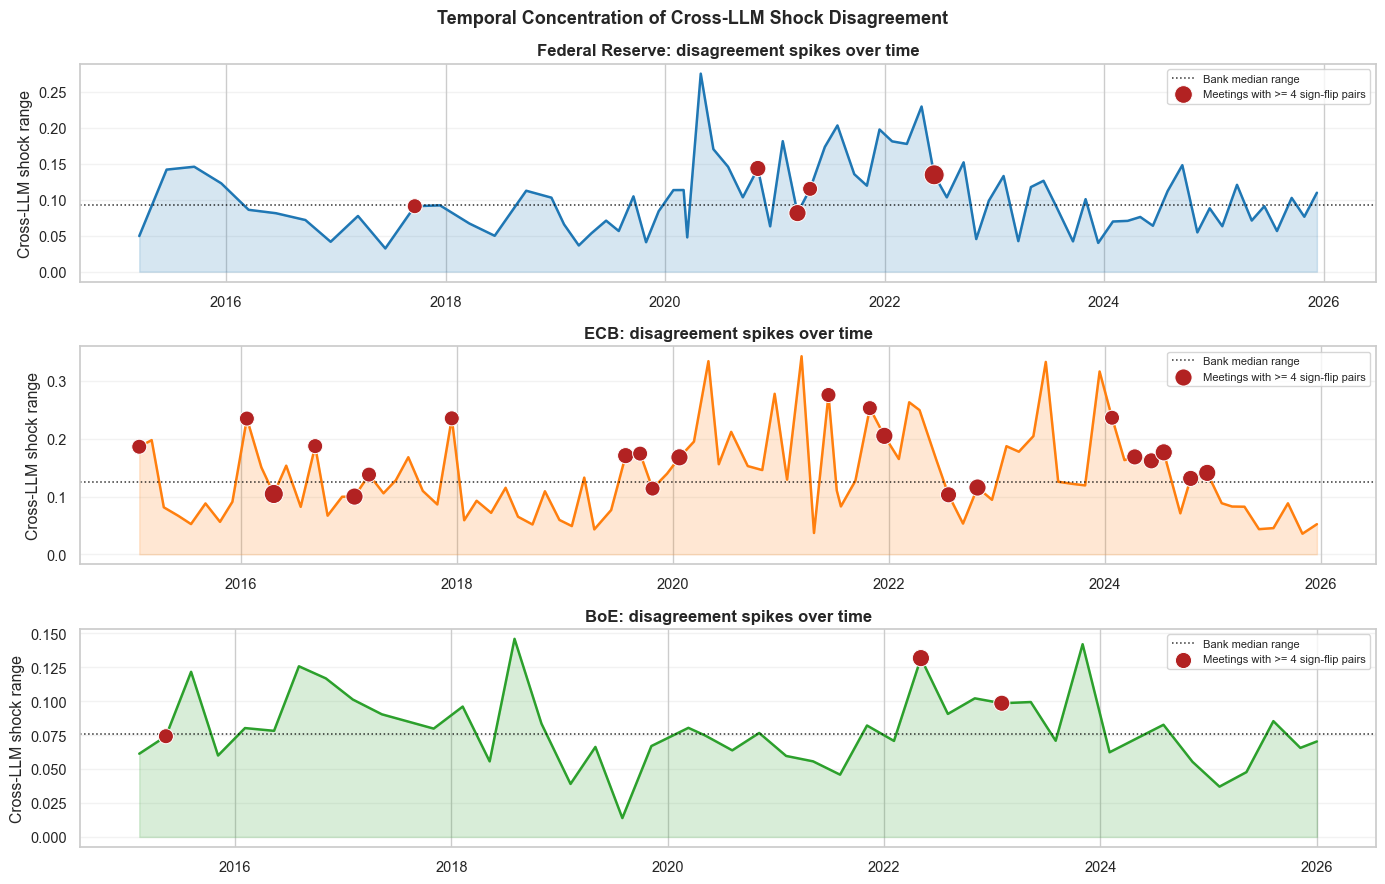

Temporal takeaway:
  Federal Reserve: the largest disagreement spike occurs on 2020-04-29 (range=0.275, sign flips=0/15). There are 5 meetings with at least 4 sign-flip pairs.
  ECB: the largest disagreement spike occurs on 2021-03-11 (range=0.343, sign flips=0/15). There are 22 meetings with at least 4 sign-flip pairs.
  BoE: the largest disagreement spike occurs on 2018-08-02 (range=0.146, sign flips=0/15). There are 3 meetings with at least 4 sign-flip pairs.


In [8]:
timeline_threshold = 4
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
bank_colors = {"fed": "#1f77b4", "ecb": "#ff7f0e", "boe": "#2ca02c"}

for ax, bank in zip(axes, BANKS):
    sub = meeting_disagreement[meeting_disagreement["bank"] == bank].sort_values("date").copy()
    x = sub["date"]
    y = sub["cross_llm_range"]
    ax.fill_between(x, 0, y, color=bank_colors[bank], alpha=0.18)
    ax.plot(x, y, color=bank_colors[bank], linewidth=1.8)
    ax.axhline(sub["cross_llm_range"].median(), color="black", linestyle=":", linewidth=1.1, alpha=0.8, label="Bank median range")

    spike = sub[sub["n_sign_flip_pairs"] >= timeline_threshold]
    ax.scatter(
        spike["date"],
        spike["cross_llm_range"],
        s=45 + 18 * spike["n_sign_flip_pairs"],
        color="#b22222",
        edgecolor="white",
        linewidth=0.7,
        zorder=4,
        label=f"Meetings with >= {timeline_threshold} sign-flip pairs",
    )

    ax.set_title(f"{BANK_LABEL[bank]}: disagreement spikes over time", fontsize=12, fontweight="bold")
    ax.set_ylabel("Cross-LLM shock range")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right", fontsize=8, frameon=True)

plt.suptitle("Temporal Concentration of Cross-LLM Shock Disagreement", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "residual_similarity_timeline.png", dpi=160, bbox_inches="tight")
plt.show()

print("Temporal takeaway:")
for bank in BANKS:
    sub = meeting_disagreement[meeting_disagreement["bank"] == bank]
    max_row = sub.sort_values(["cross_llm_range", "n_sign_flip_pairs"], ascending=[False, False]).iloc[0]
    spike_count = int((sub["n_sign_flip_pairs"] >= timeline_threshold).sum())
    print(
        f"  {BANK_LABEL[bank]}: the largest disagreement spike occurs on {max_row['date_str']} "
        f"(range={max_row['cross_llm_range']:.3f}, sign flips={int(max_row['n_sign_flip_pairs'])}/15). "
        f"There are {spike_count} meetings with at least {timeline_threshold} sign-flip pairs."
    )


In [9]:
top_rows = []

for bank in BANKS:
    sub = meeting_disagreement[meeting_disagreement["bank"] == bank].copy()
    top_flip = sub.sort_values(["n_sign_flip_pairs", "cross_llm_range"], ascending=[False, False]).head(5).copy()
    top_flip["rank_type"] = "top_sign_flips"
    top_range = sub.sort_values(["cross_llm_range", "n_sign_flip_pairs"], ascending=[False, False]).head(5).copy()
    top_range["rank_type"] = "top_range"
    top_rows.extend([top_flip, top_range])

residual_contested_meetings_top = pd.concat(top_rows, ignore_index=True)
residual_contested_meetings_top = residual_contested_meetings_top.sort_values(
    ["bank", "rank_type", "n_sign_flip_pairs", "cross_llm_range"], ascending=[True, True, False, False]
).reset_index(drop=True)

for bank in BANKS:
    print(f"\n=== {BANK_LABEL[bank]}: Top 5 by sign flips ===")
    sub = residual_contested_meetings_top[
        (residual_contested_meetings_top["bank"] == bank) & (residual_contested_meetings_top["rank_type"] == "top_sign_flips")
    ].copy()
    display(
        sub[["date_str", "n_sign_flip_pairs", "share_sign_flip_pairs", "cross_llm_range", "cross_llm_std", "n_positive", "n_negative", "n_near_zero"]]
        .style.format({
            "share_sign_flip_pairs": "{:.1%}",
            "cross_llm_range": "{:.3f}",
            "cross_llm_std": "{:.3f}",
        })
    )

    print(f"{BANK_LABEL[bank]}: Top 5 by range")
    sub = residual_contested_meetings_top[
        (residual_contested_meetings_top["bank"] == bank) & (residual_contested_meetings_top["rank_type"] == "top_range")
    ].copy()
    display(
        sub[["date_str", "cross_llm_range", "cross_llm_std", "n_sign_flip_pairs", "n_positive", "n_negative", "n_near_zero"]]
        .style.format({
            "cross_llm_range": "{:.3f}",
            "cross_llm_std": "{:.3f}",
        })
    )



=== Federal Reserve: Top 5 by sign flips ===


,date_str,n_sign_flip_pairs,share_sign_flip_pairs,cross_llm_range,cross_llm_std,n_positive,n_negative,n_near_zero
25,2022-06-15,9,60.0%,0.134,0.048,3,3,0
26,2021-03-17,6,40.0%,0.081,0.031,3,2,1
27,2020-11-05,5,33.3%,0.143,0.044,1,5,0
28,2021-04-28,4,26.7%,0.115,0.041,2,2,2
29,2017-09-20,4,26.7%,0.091,0.034,4,1,1


Federal Reserve: Top 5 by range


,date_str,cross_llm_range,cross_llm_std,n_sign_flip_pairs,n_positive,n_negative,n_near_zero
20,2021-07-28,0.203,0.065,3,3,1,2
21,2020-04-29,0.275,0.088,0,0,6,0
22,2022-05-04,0.229,0.081,0,6,0,0
23,2021-12-15,0.197,0.058,0,6,0,0
24,2021-01-27,0.181,0.058,0,0,5,1



=== ECB: Top 5 by sign flips ===


...

,date_str,cross_llm_range,cross_llm_std,n_sign_flip_pairs,n_positive,n_negative,n_near_zero
10,2021-03-11,0.343,0.111,0,0,5,1
11,2020-04-30,0.334,0.112,0,0,6,0
12,2023-06-15,0.333,0.115,0,5,0,1
13,2023-12-14,0.317,0.129,0,3,0,3
14,2020-12-10,0.278,0.095,0,0,6,0



=== BoE: Top 5 by sign flips ===


,date_str,n_sign_flip_pairs,share_sign_flip_pairs,cross_llm_range,cross_llm_std,n_positive,n_negative,n_near_zero
5,2022-05-05,6,40.0%,0.132,0.044,3,2,1
6,2023-02-02,5,33.3%,0.099,0.036,1,5,0
7,2015-05-13,4,26.7%,0.074,0.029,1,4,1
8,2023-05-11,3,20.0%,0.099,0.034,1,3,2
9,2020-11-05,3,20.0%,0.077,0.025,1,3,2


BoE: Top 5 by range


,date_str,cross_llm_range,cross_llm_std,n_sign_flip_pairs,n_positive,n_negative,n_near_zero
0,2022-05-05,0.132,0.044,6,3,2,1
1,2018-08-02,0.146,0.051,0,5,0,1
2,2023-11-02,0.142,0.048,0,6,0,0
3,2016-08-04,0.126,0.043,0,0,6,0
4,2015-08-06,0.122,0.040,0,6,0,0


In [10]:
def meeting_sign_string(bank: str, date: pd.Timestamp) -> str:
    row = shock_dfs[bank].loc[date]
    signs = sign_with_band(row, zero_band=ZERO_BAND)
    out = []
    for llm in LLMS:
        label = "H" if signs[llm] == 1 else "D" if signs[llm] == -1 else "N"
        out.append(f"{LLM_SHORT[llm]}:{label} ({row[llm]:+.3f})")
    return " | ".join(out)


for bank in BANKS:
    sub = meeting_disagreement[meeting_disagreement["bank"] == bank]
    contested = sub[sub["n_sign_flip_pairs"] > 0].sort_values(["n_sign_flip_pairs", "cross_llm_range"], ascending=[False, False]).head(5)
    if contested.empty:
        print(f"\n{BANK_LABEL[bank]} has no meetings with sign flips under the current zero band.")
        continue
    print(f"\n{BANK_LABEL[bank]} contested meetings with sign strings:")
    for _, r in contested.iterrows():
        print(
            f"  {r['date_str']}  flips={r['n_sign_flip_pairs']}/15  range={r['cross_llm_range']:.3f}  "
            f"{meeting_sign_string(bank, r['date'])}"
        )



Federal Reserve contested meetings with sign strings:
  2022-06-15  flips=9/15  range=0.134  DeepSeek:H (+0.028) | Gemini:D (-0.057) | GPT-4o:D (-0.020) | Llama:H (+0.024) | Mistral:H (+0.061) | Qwen:D (-0.073)
  2021-03-17  flips=6/15  range=0.081  DeepSeek:H (+0.033) | Gemini:D (-0.047) | GPT-4o:H (+0.026) | Llama:N (+0.001) | Mistral:H (+0.034) | Qwen:D (-0.024)
  2020-11-05  flips=5/15  range=0.143  DeepSeek:H (+0.043) | Gemini:D (-0.052) | GPT-4o:D (-0.060) | Llama:D (-0.072) | Mistral:D (-0.100) | Qwen:D (-0.036)
  2021-04-28  flips=4/15  range=0.115  DeepSeek:H (+0.070) | Gemini:D (-0.045) | GPT-4o:H (+0.058) | Llama:D (-0.021) | Mistral:N (-0.004) | Qwen:N (+0.002)
  2017-09-20  flips=4/15  range=0.091  DeepSeek:D (-0.027) | Gemini:H (+0.056) | GPT-4o:N (+0.001) | Llama:H (+0.064) | Mistral:H (+0.051) | Qwen:H (+0.051)

ECB contested meetings with sign strings:
  2016-04-21  flips=8/15  range=0.104  DeepSeek:H (+0.020) | Gemini:D (-0.037) | GPT-4o:D (-0.058) | Llama:H (+0.030)

## 5. Paper-Facing Event Drill-Down

We surface one focal contested meeting per bank, and explicitly include the Fed's 2015-08-06 meeting if it exists in the residuals.


In [11]:
selected_meetings = {}
for bank in BANKS:
    sub = meeting_disagreement[meeting_disagreement["bank"] == bank]
    best = sub.sort_values(["n_sign_flip_pairs", "cross_llm_range"], ascending=[False, False]).iloc[0]
    selected_meetings[bank] = pd.Timestamp(best["date"])

fed_worked_example = pd.Timestamp("2015-08-06")
has_fed_worked_example = fed_worked_example in shock_dfs["fed"].index

print("Selected focal meetings:")
for bank, date in selected_meetings.items():
    print(f"  {BANK_LABEL[bank]}: {date.strftime('%Y-%m-%d')}")
print(f"Include explicit Fed 2015-08-06 example: {has_fed_worked_example}")


Selected focal meetings:
  Federal Reserve: 2022-06-15
  ECB: 2016-04-21
  BoE: 2022-05-05
Include explicit Fed 2015-08-06 example: False


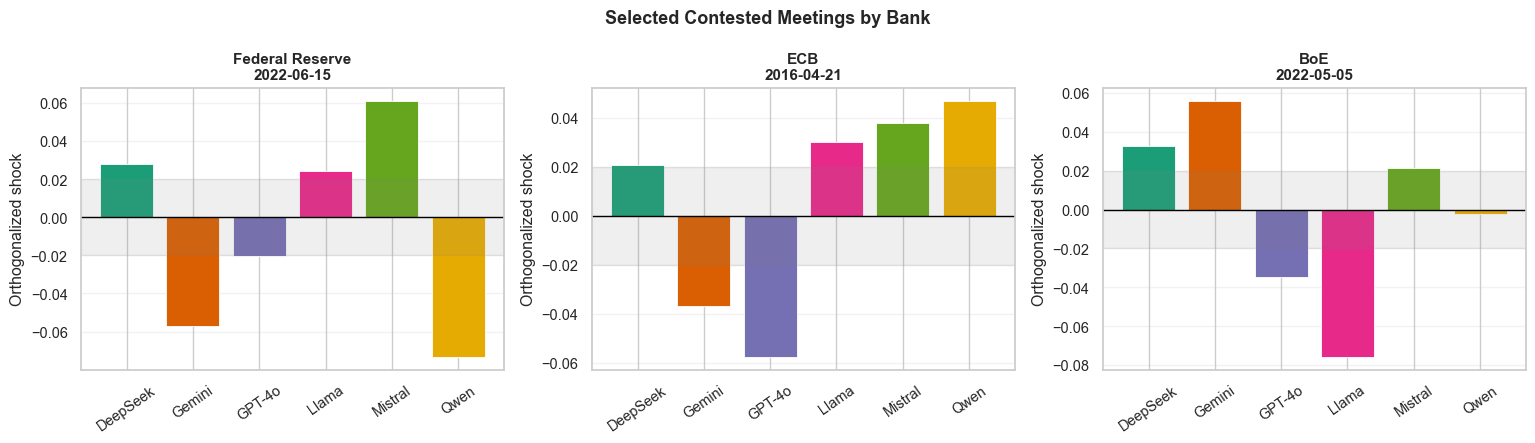

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5), sharey=False)

for ax, bank in zip(axes, BANKS):
    date = selected_meetings[bank]
    row = shock_dfs[bank].loc[date, LLMS]
    colors = [LLM_COLOR[llm] for llm in LLMS]
    ax.bar([LLM_SHORT[llm] for llm in LLMS], row.values, color=colors, edgecolor="white", linewidth=0.6)
    ax.axhline(0, color="black", linewidth=1)
    ax.axhspan(-ZERO_BAND, ZERO_BAND, color="gray", alpha=0.12)
    ax.set_title(f"{BANK_LABEL[bank]}\n{date.strftime('%Y-%m-%d')}", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=35)
    ax.set_ylabel("Orthogonalized shock")
    ax.grid(axis="y", alpha=0.25)

plt.suptitle("Selected Contested Meetings by Bank", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "residual_similarity_selected_meetings.png", dpi=160, bbox_inches="tight")
plt.show()

if has_fed_worked_example:
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    row = shock_dfs['fed'].loc[fed_worked_example, LLMS]
    ax.bar([LLM_SHORT[llm] for llm in LLMS], row.values, color=[LLM_COLOR[llm] for llm in LLMS], edgecolor='white', linewidth=0.6)
    ax.axhline(0, color='black', linewidth=1)
    ax.axhspan(-ZERO_BAND, ZERO_BAND, color='gray', alpha=0.12)
    ax.set_title('Fed Worked Example: 2015-08-06', fontsize=13, fontweight='bold')
    ax.set_ylabel('Orthogonalized shock')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'residual_similarity_fed_2015_08_06.png', dpi=160, bbox_inches='tight')
    plt.show()

    fed_row = meeting_disagreement[(meeting_disagreement['bank'] == 'fed') & (meeting_disagreement['date'] == fed_worked_example)]
    if not fed_row.empty:
        r = fed_row.iloc[0]
        print(
            f"Fed 2015-08-06: range={r['cross_llm_range']:.3f}, std={r['cross_llm_std']:.3f}, "
            f"sign flips={int(r['n_sign_flip_pairs'])}/15, signs -> {meeting_sign_string('fed', fed_worked_example)}"
        )


In [13]:
print("Ready-to-copy paragraph templates:\n")
for bank in BANKS:
    summary = bank_summary.loc[bank_summary['bank'] == bank].iloc[0]
    top = meeting_disagreement[meeting_disagreement['bank'] == bank].sort_values(
        ['n_sign_flip_pairs', 'cross_llm_range'], ascending=[False, False]
    ).iloc[0]
    print(f"[{BANK_LABEL[bank]}]")
    print(
        f"The orthogonalized communication shocks extracted by the six LLMs remain highly similar on average for the {BANK_LABEL[bank]}: "
        f"the mean pairwise correlation of the shock series is {summary['mean_pairwise_pearson']:.3f}, and the mean same-sign rate is "
        f"{summary['mean_same_sign_rate']:.1%}. At the same time, this average similarity masks substantial disagreement for specific meetings. "
        f"The most contested {BANK_LABEL[bank]} meeting in the sample is {top['date_str']}, for which the cross-LLM shock range is "
        f"{top['cross_llm_range']:.3f} and {int(top['n_sign_flip_pairs'])} of the 15 model pairs imply opposite shock signs."
    )
    print()


Ready-to-copy paragraph templates:

[Federal Reserve]
The orthogonalized communication shocks extracted by the six LLMs remain highly similar on average for the Federal Reserve: the mean pairwise correlation of the shock series is 0.897, and the mean same-sign rate is 73.4%. At the same time, this average similarity masks substantial disagreement for specific meetings. The most contested Federal Reserve meeting in the sample is 2022-06-15, for which the cross-LLM shock range is 0.134 and 9 of the 15 model pairs imply opposite shock signs.

[ECB]
The orthogonalized communication shocks extracted by the six LLMs remain highly similar on average for the ECB: the mean pairwise correlation of the shock series is 0.784, and the mean same-sign rate is 67.0%. At the same time, this average similarity masks substantial disagreement for specific meetings. The most contested ECB meeting in the sample is 2016-04-21, for which the cross-LLM shock range is 0.104 and 8 of the 15 model pairs imply opp

## 6. Exports for the Paper and Later Mechanism Work

Save core tables and keep the main objects in memory for later downstream extensions.


In [14]:
bank_summary_path = ROBUSTNESS_DIR / "residual_similarity_bank_summary.csv"
pairwise_path = ROBUSTNESS_DIR / "residual_similarity_pairwise.csv"
meeting_path = ROBUSTNESS_DIR / "residual_disagreement_meeting_level.csv"
contested_path = ROBUSTNESS_DIR / "residual_contested_meetings_top.csv"

bank_summary.to_csv(bank_summary_path, index=False)
pairwise_similarity.to_csv(pairwise_path, index=False)
meeting_disagreement.to_csv(meeting_path, index=False)
residual_contested_meetings_top.to_csv(contested_path, index=False)

print("Saved CSV outputs:")
for path in [bank_summary_path, pairwise_path, meeting_path, contested_path]:
    print(f"  -> {path.relative_to(ROOT)}")

print("\nSaved figures:")
figure_names = [
    "residual_similarity_heatmaps.png",
    "residual_similarity_summary.png",
    "residual_similarity_selected_meetings.png",
    "residual_similarity_timeline.png",
]
if has_fed_worked_example:
    figure_names.append("residual_similarity_fed_2015_08_06.png")
for name in figure_names:
    print(f"  -> output/figures/{name}")

print("\nObjects left in memory for the next bridge stage:")
print("  shock_dfs")
print("  similarity_mats")
print("  pairwise_similarity")
print("  bank_summary")
print("  meeting_disagreement")
print("  residual_contested_meetings_top")


Saved CSV outputs:
  -> output\causal-machinery\robustness\residual_similarity_bank_summary.csv
  -> output\causal-machinery\robustness\residual_similarity_pairwise.csv
  -> output\causal-machinery\robustness\residual_disagreement_meeting_level.csv
  -> output\causal-machinery\robustness\residual_contested_meetings_top.csv

Saved figures:
  -> output/figures/residual_similarity_heatmaps.png
  -> output/figures/residual_similarity_summary.png
  -> output/figures/residual_similarity_selected_meetings.png
  -> output/figures/residual_similarity_timeline.png

Objects left in memory for the next bridge stage:
  shock_dfs
  similarity_mats
  pairwise_similarity
  bank_summary
  meeting_disagreement
  residual_contested_meetings_top
